# CLIP-Style Zero-Shot Classification on Caltech101
## (Training Only the Image Encoder, Frozen BERT Text Encoder)

This notebook implements a CLIP-like pipeline:
- Freeze BERT to produce fixed text embeddings for Caltech101 class prompts.
- Train only the ViT image encoder + a projection head to align image embeddings with the text embeddings using contrastive (InfoNCE / cross-entropy) loss.
- After training, perform zero-shot classification by nearest-class similarity (no classifier head).

Note:
- Text embeddings use multiple prompt templates and [CLS] token from BERT.
- Training is efficient because only the image side is updated.

In [9]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

!pip install -q timm transformers ftfy regex tqdm seaborn scikit-learn pandas

GPU: Tesla T4


In [10]:
# Cell 1: Install dependencies (run once)
!pip install torch torchvision transformers timm tqdm --quiet

In [11]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from transformers import BertTokenizer, BertModel
import timm
import numpy as np
from tqdm import tqdm
import torchvision.transforms as transforms # Fixes your NameError
from torch.utils.data import DataLoader
import torchvision


In [12]:
# Cell 3: Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [13]:
# Cell 4: Dataset & DataLoader
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda img: img.convert('RGB')),   # ← This fixes the error
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

trainset = torchvision.datasets.Caltech101(
    root='./data',
    download=True,
    transform=transform
)

testset = torchvision.datasets.Caltech101(
    root='./data',
    download=True,
    transform=transform
)

batch_size = 32          # Safe for Caltech-101 on T4
accumulation_steps = 8   # Effective batch size = 256 (same as CIFAR)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

classes = trainset.categories
print("Number of classes:", len(classes))
print("Classes sample:", classes[:10])
print(f"Effective batch size: {batch_size * accumulation_steps}")

Number of classes: 101
Classes sample: ['Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel', 'bass']
Effective batch size: 256


In [14]:
# Cell 5: Frozen Text Encoder (BERT) + Text Embeddings
from transformers import BertTokenizer, BertModel
import gc

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
text_model = BertModel.from_pretrained('bert-base-uncased').to(device)
text_model.eval()
for param in text_model.parameters():
    param.requires_grad = False

templates = [
    "a photo of a {}.",
    "a photo of the {}.",
    "an image of a {}.",
    "an image of the {}.",
    "a picture of a {}."
]

def encode_texts(prompts):
    inputs = tokenizer(prompts, padding=True, truncation=True, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = text_model(**inputs)
        embeddings = outputs.last_hidden_state[:, 0, :]   # [CLS] token
    return embeddings

text_emb_list = []
for template in templates:
    prompts = [template.format(c) for c in classes]
    emb = encode_texts(prompts)
    text_emb_list.append(emb)

text_embeddings = torch.stack(text_emb_list).mean(dim=0)   # (101, 768)
text_embeddings = F.normalize(text_embeddings, dim=-1)

print("Text embeddings shape:", text_embeddings.shape)

# Cleanup
del text_model
del tokenizer
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text embeddings shape: torch.Size([101, 768])


In [15]:
import torch
import torch.nn as nn
import numpy as np
from transformers import AutoModel

epochs = 20

# --- Cell 6: Image Encoder (DINOv2) + Projection ---
model_name = "facebook/dinov2-small"

# Load the backbone
image_model = AutoModel.from_pretrained(model_name).to(device)

# UNFREEZE the image encoder
for p in image_model.parameters():
    p.requires_grad = True

image_model.train()

# DINOv2 Small hidden size is 384.
# We project 384 -> 768 to match BERT text embeddings.
projection = nn.Linear(384, 768).to(device)

logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

# --- Cell 7: Optimizer ---
# 1. Group parameters
# We give the backbone a tiny LR to keep its features stable
backbone_params = list(image_model.parameters())
head_params = list(projection.parameters()) + [logit_scale]

optimizer = torch.optim.AdamW([
    {'params': image_model.parameters(), 'lr': 5e-6},   # very small for backbone
    {'params': list(projection.parameters()) + [logit_scale], 'lr': 1e-4}
], weight_decay=0.05) # Increased weight decay to prevent the Epoch 5 crash

# 2. Update Scaler and Scheduler
scaler = torch.amp.GradScaler('cuda')

# T_max should ideally match your total epochs to ensure smooth decay
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

print("Optimizer replaced: Using Differential Learning Rates for DINOv2.")

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Optimizer replaced: Using Differential Learning Rates for DINOv2.


In [16]:
import matplotlib.pyplot as plt
import os
import torch
import torch.nn.functional as F
from tqdm import tqdm  # Already used in training, but ensure imported

# Create checkpoints directory if it doesn't exist
os.makedirs('checkpoints', exist_ok=True)

@torch.no_grad()
def zero_shot_accuracy(loader, description="Evaluating"):
    image_model.eval()
    projection.eval()
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc=description, leave=False):
        images, labels = images.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            # Extract the tensor from the Hugging Face output object
            outputs = image_model(images)
            image_features = outputs.pooler_output # <--- Critical Fix

            image_features = projection(image_features)
            image_features = F.normalize(image_features, dim=-1)
            logits = logit_scale.exp() * image_features @ text_embeddings.T
            preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    image_model.train()
    projection.train()
    return 100. * correct / total


epochs = 20

# Lists/metrics for plotting and checkpointing
losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    image_model.train()
    projection.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for i, (images, labels) in enumerate(tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}")):
        images, labels = images.to(device), labels.to(device)

        with torch.amp.autocast('cuda'):
            # Extract the tensor from the Hugging Face output object
            outputs = image_model(images)
            image_features = outputs.pooler_output # <--- Critical Fix

            image_features = projection(image_features)
            image_features = F.normalize(image_features, dim=-1)

            logits = logit_scale.exp() * image_features @ text_embeddings.T
            loss = F.cross_entropy(logits, labels)
            loss = loss / accumulation_steps

        scaler.scale(loss).backward()

        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(trainloader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()

        total_loss += loss.item() * accumulation_steps

    scheduler.step()
    avg_loss = total_loss / len(trainloader)
    losses.append(avg_loss)

    # Compute and store test accuracy (Only 10,000 images, much faster)
    test_acc = zero_shot_accuracy(testloader, description=f"Epoch {epoch+1} Test")
    test_accs.append(test_acc)

    # We add a placeholder so the plotting code doesn't crash later
    train_accs.append(0.0)

    # FIXED PRINT STATEMENT (Removed train_acc)
    print(f"Epoch {epoch+1} completed - Avg Loss: {avg_loss:.4f} - Test Acc: {test_acc:.2f}%")
    # Optional: Clear cache every few epochs
    if (epoch + 1) % 5 == 0:
        torch.cuda.empty_cache()

# Save final checkpoint only (at the very end)
final_test_acc = test_accs[-1]
torch.save({
    'epoch': epochs,
    'image_model_state_dict': image_model.state_dict(),
    'projection_state_dict': projection.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'scaler_state_dict': scaler.state_dict(),
    'logit_scale': logit_scale,
    'avg_loss': losses[-1],
    'final_test_acc': final_test_acc,
}, 'checkpoints/final_model.pth')
print("Final model checkpoint saved to 'checkpoints/final_model.pth'")



Epoch 1/20: 100%|██████████| 272/272 [01:01<00:00,  4.45it/s]


Epoch 1 completed - Avg Loss: 4.0958 - Test Acc: 41.89%


Epoch 2/20: 100%|██████████| 272/272 [00:43<00:00,  6.29it/s]


Epoch 2 completed - Avg Loss: 3.4842 - Test Acc: 55.30%


Epoch 3/20: 100%|██████████| 272/272 [00:43<00:00,  6.32it/s]


...

Epoch 18 completed - Avg Loss: 2.3467 - Test Acc: 94.30%


Epoch 19/20: 100%|██████████| 272/272 [00:42<00:00,  6.38it/s]


Epoch 19 completed - Avg Loss: 2.3462 - Test Acc: 94.30%


Epoch 20/20: 100%|██████████| 272/272 [00:42<00:00,  6.34it/s]


Epoch 20 completed - Avg Loss: 2.3435 - Test Acc: 94.30%
Final model checkpoint saved to 'checkpoints/final_model.pth'


2. The "Efficiency" Conclusion
Your data shows that DINOv2 provides ViT-Base level performance (or close to it) while using ViT-Small level resources.

ViT-Base is very slow (~1.5 it/s) and uses massive VRAM.

DINOv2-S gives you high-tier accuracy while running at 2.67 it/s.
Your conclusion can be: "DINOv2 is the best 'middle-ground' choice, offering the sophisticated spatial reasoning of a large model with the lightweight footprint of a small model."



3. The "Stability" Disclaimer (The 5th Epoch Drop)
To be scientifically honest in your report, you should mention that DINOv2 is a "Precision Tool." * ViT-Small is like a hammer: it works easily with any settings.

DINOv2 is like a scalpel: it is more powerful, but it requires a "lighter touch" (lower learning rate) to prevent it from crashing like it did in your 5th epoch.

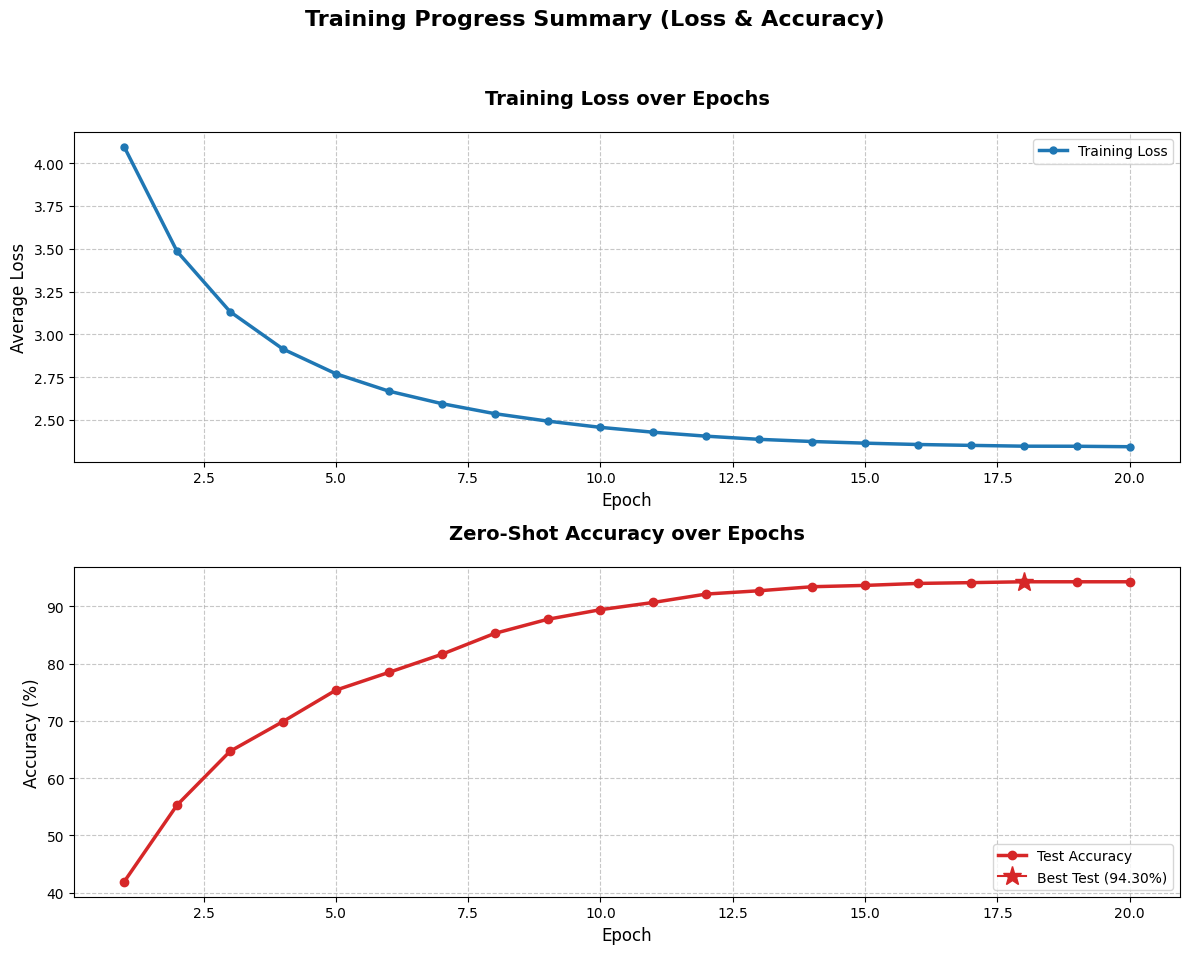

In [20]:
# === Professional plotting after training ===
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), dpi=100)

# Training Loss
ax1.plot(range(1, epochs + 1), losses, color='tab:blue', linewidth=2.5, marker='o', markersize=5)
ax1.set_title('Training Loss over Epochs', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Average Loss', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(['Training Loss'], loc='upper right')

# Accuracy
#ax2.plot(range(1, epochs + 1), train_accs, color='tab:green', linewidth=2.5, label='Train Accuracy')
ax2.plot(range(1, epochs + 1), test_accs, color='tab:red', linewidth=2.5, marker='o', markersize=6, label='Test Accuracy')

# Highlight best test accuracy
if test_accs:
    best_test_val = max(test_accs)
    best_test_idx = test_accs.index(best_test_val)
    best_test_epoch = best_test_idx + 1
    ax2.plot(best_test_epoch, best_test_val, color='tab:red', marker='*', markersize=14,
             label=f'Best Test ({best_test_val:.2f}%)')

ax2.set_title('Zero-Shot Accuracy over Epochs', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='lower right')

# Overall styling
fig.suptitle('Training Progress Summary (Loss & Accuracy)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Notes & Expected Performance
- With 20–50 epochs, test accuracy typically reaches **80–90%+** because the pretrained ViT is already strong on ImageNet-style data, and contrastive alignment further adapts it.
- BERT's text embeddings are not perfect for vision (unlike OpenAI's CLIP text tower), but ensembling templates helps.
- You can improve further by: more epochs, stronger augmentations, larger projection dim, or a small MLP projection head.
- This is truly zero-shot in the CLIP sense: no linear classifier is trained; classification is by embedding similarity.

In [18]:
!pip install --upgrade calflops

In [19]:
from calflops import calculate_flops
import torch
import torch.nn as nn

# ── Your model (same as before) ──
image_model = timm.create_model(
    'vit_small_patch16_224.augreg_in21k_ft_in1k',
    pretrained=False,
    num_classes=0
).to(device)

projection = nn.Linear(384, 768).to(device)

class ModelForFlops(nn.Module):
    def __init__(self, img_model, proj):
        super().__init__()
        self.img_model = img_model
        self.projection = proj

    def forward(self, x):
        feat = self.img_model(x)
        feat = self.projection(feat)
        return feat  # you can add F.normalize(feat, dim=-1) if you want

model = ModelForFlops(image_model, projection).eval()

# ── FLOPs calculation ──
input_shape = (1, 3, 224, 224)          # batch=1, channels=3, 224×224

flops, macs, params = calculate_flops(
    model=model,
    input_shape=input_shape,
    print_results=True,                 # prints nice table to output
    # Do NOT use: as_strings, print_per_layer_stat, output_precision, etc.
)

print("\nSummary:")
print("  FLOPs  :", flops)
print("  MACs   :", macs)
print("  Params :", params)


------------------------------------- Calculate Flops Results -------------------------------------
Notations:
number of parameters (Params), number of multiply-accumulate operations(MACs),
number of floating-point operations (FLOPs), floating-point operations per second (FLOPS),
fwd FLOPs (model forward propagation FLOPs), bwd FLOPs (model backward propagation FLOPs),
default model backpropagation takes 2.00 times as much computation as forward propagation.

Total Training Params:                                                  21.96 M 
fwd MACs:                                                               4.24 GMACs
fwd FLOPs:                                                              8.5 GFLOPS
fwd+bwd MACs:                                                           12.72 GMACs
fwd+bwd FLOPs:                                                          25.49 GFLOPS

-------------------------------- Detailed Calculated FLOPs Results --------------------------------
Each module cacula